# Enduro VoC-v14 qualification RMSE RCA

## tl;dr

- The sealed v14 `logs.csv` validates at SHA-256 `6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8`. It has 922 unique columns and 204/204 complete rows with strictly increasing, unique integer `real_step` values.
- The frozen population is exactly `70000 < real_step <= 100000`: 63 rows, steps 70,032 through 99,376, support 7,703. The sole overshoot row at 100,112 is excluded.
- Pooled held-out selected-action TD RMSE is **0.5247954789453232 for EMA Q** and **0.5248123566562356 for online Q**, so EMA exceeds the preregistered 0.5 ceiling by 0.0247955. EMA SSE is 2,121.4855 versus a 1,925.75 threshold budget, an excess of 195.7355 (10.1641%).
- EMA held-out bias is -0.0173424 and MAE is 0.2182068. Even the optimistic global constant-bias lower bound is 0.5245088518192085, still above 0.5. W1/W2/W3 EMA RMSE is 0.3070468 / 0.4805763 / 0.8753411; the late W3 window carries the largest error.
- Row SSE is concentrated: the top 1 / 5 / 10 rows contribute 14.6652% / 54.5389% / 79.9905% of EMA held-out SSE. This is a concentration diagnostic, not permission to remove observations.
- The corrected frozen online-vs-EMA delta-sign agreement is 46,420 / 61,714 = 0.7521794082380011. The separate EMA-Q-vs-exact-projected-gate diagnostic is 61,715 / 61,715 = 1.0; these are different comparisons.
- Reconstructed full train half-MSE is 0.1721628949 versus logged mean Smooth-L1/Huber 0.1242177419. The identity `MSE - 2*Huber = 0.0958903061` quantifies squared tail excess beyond the Huber quadratic region.

> **Interpretation boundary:** this notebook is a descriptive reconciliation of sealed telemetry. It is not a causal analysis and does not simulate, authorize, or estimate the effect of a retrain or post-hoc row removal.


## Context & Methods

The diagnostic question is narrow: reproduce the failed v14 held-out EMA RMSE gate, reconcile nearby online-Q and training-loss telemetry, and describe where the squared error is concentrated. The source of truth is the sealed CSV path and hash below.

### Key assumptions and frozen algebra

- Population: rows satisfying the strict predicate `70000 < real_step <= 100000`, in CSV order.
- For row support `n_i` and row RMSE `r_i`, `SSE_i = n_i * r_i**2` and pooled RMSE is `sqrt(sum(SSE_i) / sum(n_i))`.
- Bias and MAE are pooled as support-weighted row means. The 0.5 RMSE ceiling corresponds to an SSE budget of `0.5**2 * total_support`.
- Event rates are converted back to integer successes as `round(n_i * rate_i)` only when every rounding residual is at most `1e-4`, then numerators and denominators are summed.
- Train SSE is reconstructed row by row from all-online SSE less held-out-online SSE, using `N_all = N_train + N_holdout`. The logged `actor/voc_q_loss` is mean default Smooth-L1 (Huber with beta 1) over the train mask.
- v11/v12 are contextual comparisons only and are included only after exact file-hash and required-column validation. Their different row cadence and support prevent a causal mechanism-effect interpretation.

The notebook is executed with the production Python 3.10 interpreter recorded in the setup cell. Calculations use float64 after CSV parsing; no data are rewritten.


In [1]:
from pathlib import Path
import csv
import hashlib
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PRODUCTION_PYTHON = Path('/home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python')
SOURCE = Path('/tmp/di-voc-v14-sealed-eps25-final-eKgdrk/runs/enduro-voc-v14-sealed-eps25-seed1-qual-fresh-100k/logs.csv')
EXPECTED_SHA256 = '6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8'
LOWER_STEP = 70_000
UPPER_STEP = 100_000
RMSE_CEILING = 0.5
WINDOWS = (
    ('W1', 70_000, 80_000),
    ('W2', 80_000, 90_000),
    ('W3', 90_000, 100_000),
)

assert sys.version_info[:2] == (3, 10), sys.version
assert Path(sys.executable).resolve() == PRODUCTION_PYTHON.resolve(), sys.executable
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

print(f'Python: {platform.python_version()}')
print(f'Executable: {sys.executable}')
print(f'pandas={pd.__version__}, numpy={np.__version__}, matplotlib={plt.matplotlib.__version__}')


Python: 3.10.21
Executable: /home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python
pandas=2.3.3, numpy=1.26.4, matplotlib=3.10.9


## Data

### 1. Load and validate the sealed v14 CSV

Raw-header validation occurs before pandas parsing so duplicate CSV headers cannot be hidden by automatic name mangling. All assertions fail closed.


In [2]:
assert SOURCE.is_file(), SOURCE
source_sha256 = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
assert source_sha256 == EXPECTED_SHA256, source_sha256

with SOURCE.open('r', encoding='utf-8', newline='') as handle:
    raw_header = next(csv.reader(handle))
assert len(raw_header) == 922
assert len(set(raw_header)) == 922

logs = pd.read_csv(SOURCE)
assert logs.shape == (204, 922), logs.shape
assert list(logs.columns) == raw_header
complete_rows = int(logs.notna().all(axis=1).sum())
assert complete_rows == 204

steps = pd.to_numeric(logs['real_step'], errors='raise').to_numpy(dtype=np.float64)
assert np.isfinite(steps).all()
assert np.equal(steps, np.rint(steps)).all()
assert np.all(np.diff(steps) > 0)
assert logs['real_step'].is_unique

qual = logs.loc[(logs['real_step'] > LOWER_STEP) & (logs['real_step'] <= UPPER_STEP)].copy()
overshoot_steps = logs.loc[logs['real_step'] > UPPER_STEP, 'real_step'].astype(int).tolist()
assert len(qual) == 63
assert (int(qual['real_step'].iloc[0]), int(qual['real_step'].iloc[-1])) == (70_032, 99_376)
assert overshoot_steps == [100_112]
assert int(qual.notna().all(axis=1).sum()) == 63

data_quality = pd.DataFrame([
    ('SHA-256 matches sealed identity', source_sha256 == EXPECTED_SHA256, source_sha256),
    ('Raw columns are unique', len(set(raw_header)) == 922, '922 / 922'),
    ('Rows are complete', complete_rows == len(logs), f'{complete_rows} / {len(logs)}'),
    ('real_step is finite integer', True, f'{int(steps.min())} .. {int(steps.max())}'),
    ('real_step is strictly increasing', bool(np.all(np.diff(steps) > 0)), 'all adjacent deltas > 0'),
    ('real_step is unique', bool(logs['real_step'].is_unique), f'{logs.real_step.nunique()} / {len(logs)}'),
    ('Frozen population exact', len(qual) == 63, '63 rows: 70032 .. 99376'),
    ('Overshoot excluded', overshoot_steps == [100_112], '100112'),
], columns=['check', 'pass', 'evidence'])
display(data_quality)


,check,pass,evidence
0,SHA-256 matches sealed identity,True,6d72052279a59983d102bed3db767b3792b115d221f155...
1,Raw columns are unique,True,922 / 922
2,Rows are complete,True,204 / 204
3,real_step is finite integer,True,480 .. 100112
4,real_step is strictly increasing,True,all adjacent deltas > 0
5,real_step is unique,True,204 / 204
6,Frozen population exact,True,63 rows: 70032 .. 99376
7,Overshoot excluded,True,100112


## Results

### 2. Reproduce held-out EMA and online calibration


In [3]:
HOLDOUT_COUNT = 'actor/voc_holdout_count'
EMA_PREFIX = 'actor/voc_gate_holdout'
ONLINE_PREFIX = 'actor/voc_holdout'
REQUIRED_CALIBRATION_COLUMNS = [
    HOLDOUT_COUNT,
    *[f'{prefix}_td_{metric}' for prefix in (EMA_PREFIX, ONLINE_PREFIX) for metric in ('bias', 'mae', 'rmse')],
]
missing = sorted(set(REQUIRED_CALIBRATION_COLUMNS) - set(qual.columns))
assert not missing, missing

def require_integer_counts(series, label):
    values = pd.to_numeric(series, errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all(), label
    assert (values >= 0).all(), label
    assert np.allclose(values, np.rint(values), rtol=0.0, atol=1e-9), label
    return values.astype(np.int64)

def pooled_mean(frame, value_column, count_column=HOLDOUT_COUNT):
    count = require_integer_counts(frame[count_column], count_column).astype(np.float64)
    value = pd.to_numeric(frame[value_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(value).all(), value_column
    assert count.sum() > 0, count_column
    return float(np.dot(count, value) / count.sum())

def pooled_rmse(frame, rmse_column, count_column=HOLDOUT_COUNT):
    count = require_integer_counts(frame[count_column], count_column).astype(np.float64)
    rmse = pd.to_numeric(frame[rmse_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(rmse).all() and (rmse >= 0).all(), rmse_column
    assert count.sum() > 0, count_column
    return float(np.sqrt(np.dot(count, np.square(rmse)) / count.sum()))

def summarize_window(frame, label, lower, upper):
    window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
    return {
        'window': label,
        'predicate': f'({lower}, {upper}]',
        'rows': len(window),
        'support': int(require_integer_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum()),
        'ema_bias': pooled_mean(window, f'{EMA_PREFIX}_td_bias'),
        'ema_mae': pooled_mean(window, f'{EMA_PREFIX}_td_mae'),
        'ema_rmse': pooled_rmse(window, f'{EMA_PREFIX}_td_rmse'),
        'online_bias': pooled_mean(window, f'{ONLINE_PREFIX}_td_bias'),
        'online_mae': pooled_mean(window, f'{ONLINE_PREFIX}_td_mae'),
        'online_rmse': pooled_rmse(window, f'{ONLINE_PREFIX}_td_rmse'),
    }

window_metrics = pd.DataFrame([
    *[summarize_window(qual, label, lower, upper) for label, lower, upper in WINDOWS],
    summarize_window(qual, 'Full', LOWER_STEP, UPPER_STEP),
])

full = window_metrics.set_index('window').loc['Full']
assert int(full.support) == 7_703
assert np.isclose(full.ema_rmse, 0.5247954789453232, rtol=0.0, atol=1e-15)
assert np.isclose(full.online_rmse, 0.5248123566562356, rtol=0.0, atol=1e-15)
assert np.isclose(full.ema_bias, -0.017342407120892012, rtol=0.0, atol=1e-15)
assert np.isclose(full.ema_mae, 0.21820683345318564, rtol=0.0, atol=1e-15)

with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(window_metrics)


,window,predicate,rows,support,ema_bias,ema_mae,ema_rmse,online_bias,online_mae,online_rmse
0,W1,"(70000, 80000]",32,3647,-0.0408420105,0.0994993422,0.3070468494,-0.0408686150,0.0998501602,0.3069186481
1,W2,"(80000, 90000]",19,2485,0.0603217235,0.1892019553,0.4805763254,0.0610405140,0.1916933697,0.4812888845
2,W3,"(90000, 100000]",12,1571,-0.0856379583,0.5396602662,0.8753410807,-0.0840940710,0.5389114494,0.8748756785
3,Full,"(70000, 100000]",63,7703,-0.0173424071,0.2182068335,0.5247954789,-0.0168082496,0.2190239446,0.5248123567


### 3. Reconcile the ceiling and row-level SSE concentration

The threshold comparison is made in additive SSE space. Concentration shares describe the observed error allocation; they are not a leave-row-out qualification or a data-exclusion proposal.


In [4]:
holdout_count = require_integer_counts(qual[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
qual['ema_holdout_sse'] = holdout_count * np.square(qual[f'{EMA_PREFIX}_td_rmse'].to_numpy(dtype=np.float64))
qual['online_holdout_sse'] = holdout_count * np.square(qual[f'{ONLINE_PREFIX}_td_rmse'].to_numpy(dtype=np.float64))

total_support = int(holdout_count.sum())
ema_sse = float(qual['ema_holdout_sse'].sum())
threshold_sse = float(total_support * RMSE_CEILING**2)
excess_sse = ema_sse - threshold_sse
ema_bias = float(full.ema_bias)
optimistic_global_bias_rmse = float(np.sqrt(max(float(full.ema_rmse)**2 - ema_bias**2, 0.0)))

assert np.isclose(ema_sse, 2121.4855002393383, rtol=0.0, atol=1e-10)
assert np.isclose(threshold_sse, 1925.75, rtol=0.0, atol=1e-12)
assert np.isclose(excess_sse, 195.7355002393383, rtol=0.0, atol=1e-10)
assert np.isclose(optimistic_global_bias_rmse, 0.5245088518192085, rtol=0.0, atol=1e-15)

ceiling_reconciliation = pd.DataFrame({
    'metric': [
        'EMA pooled RMSE', 'RMSE ceiling', 'RMSE gap', 'EMA total SSE',
        'SSE budget at 0.5', 'Excess SSE', 'Excess vs SSE budget',
        'Optimistic global-bias RMSE lower bound',
    ],
    'value': [
        float(full.ema_rmse), RMSE_CEILING, float(full.ema_rmse) - RMSE_CEILING, ema_sse,
        threshold_sse, excess_sse, excess_sse / threshold_sse, optimistic_global_bias_rmse,
    ],
})

ranked_sse = qual.sort_values('ema_holdout_sse', ascending=False).copy()
concentration = pd.DataFrame([
    {
        'top_rows': top_k,
        'sse': float(ranked_sse['ema_holdout_sse'].head(top_k).sum()),
        'share_of_total_sse': float(ranked_sse['ema_holdout_sse'].head(top_k).sum() / ema_sse),
    }
    for top_k in (1, 5, 10)
])
expected_shares = {1: 0.14665166499332702, 5: 0.5453887626202633, 10: 0.7999049615724924}
for row in concentration.itertuples(index=False):
    assert np.isclose(row.share_of_total_sse, expected_shares[row.top_rows], rtol=0.0, atol=1e-15)

top_rows = ranked_sse[[
    'real_step', HOLDOUT_COUNT, f'{EMA_PREFIX}_td_bias', f'{EMA_PREFIX}_td_mae',
    f'{EMA_PREFIX}_td_rmse', 'ema_holdout_sse',
]].head(10)

with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(ceiling_reconciliation)
    display(concentration)
    display(top_rows)


,metric,value
0,EMA pooled RMSE,0.5247954789
1,RMSE ceiling,0.5000000000
2,RMSE gap,0.0247954789
3,EMA total SSE,2121.4855002393
4,SSE budget at 0.5,1925.7500000000
5,Excess SSE,195.7355002393
6,Excess vs SSE budget,0.1016411789
7,Optimistic global-bias RMSE lower bound,0.5245088518


,top_rows,sse,share_of_total_sse
0,1,311.1193808693,0.1466516650
1,5,1157.0343518924,0.5453887626
2,10,1696.9867775455,0.7999049616


,real_step,actor/voc_holdout_count,actor/voc_gate_holdout_td_bias,actor/voc_gate_holdout_td_mae,actor/voc_gate_holdout_td_rmse,ema_holdout_sse
190,89296,122.0000000000,1.0256105661,1.0693398714,1.5969216824,311.1193808693
194,92720,133.0000000000,-1.1984076500,1.1996415854,1.3576606512,245.1512450302
193,91872,133.0000000000,-0.1736219376,1.1502352953,1.2404284477,204.6421436116
201,98656,126.0000000000,0.7816775441,0.8062149286,1.2656575441,201.8380163976
161,74144,155.0000000000,-0.8614569902,0.8663570285,1.1195724010,194.2835659838
198,96192,127.0000000000,-0.4137040377,0.7399527431,1.1550832987,169.4456132159
199,97024,131.0000000000,-0.1092473790,0.7688922286,1.0381361246,141.1821863321
186,86016,127.0000000000,-0.6357414722,0.6899983287,0.8167698383,84.7233470390
200,97824,128.0000000000,-0.4887816906,0.4918248653,0.7668088078,75.2634557179
202,99376,143.0000000000,0.3013256788,0.3195669353,0.6963331699,69.3378233483


### 4. Keep the two sign-agreement diagnostics separate

`actor/voc_gate_online_delta_sign_agreement*` compares online-Q and EMA-Q non-tie delta signs. `actor/voc_gate_sign_gate_agreement_*` instead compares the EMA-Q delta sign with the soft scalar-gate sign; under exact projection that second diagnostic is perfect here.


In [5]:
def reconstruct_integer_successes(frame, count_column, rate_column, tolerance=1e-4):
    counts = require_integer_counts(frame[count_column], count_column)
    rates = pd.to_numeric(frame[rate_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(rates).all() and ((rates >= 0.0) & (rates <= 1.0)).all(), rate_column
    raw_successes = counts.astype(np.float64) * rates
    successes = np.rint(raw_successes).astype(np.int64)
    residuals = np.abs(raw_successes - successes)
    assert (residuals <= tolerance).all(), (count_column, rate_column, float(residuals.max()))
    return int(successes.sum()), int(counts.sum()), float(residuals.max())

online_ema = reconstruct_integer_successes(
    qual,
    'actor/voc_gate_online_delta_sign_agreement_count',
    'actor/voc_gate_online_delta_sign_agreement',
)
ema_projected_gate = reconstruct_integer_successes(
    qual,
    'actor/voc_gate_sign_gate_agreement_count',
    'actor/voc_gate_sign_gate_agreement_rate',
)
assert online_ema[:2] == (46_420, 61_714)
assert ema_projected_gate[:2] == (61_715, 61_715)
assert np.isclose(online_ema[0] / online_ema[1], 0.7521794082380011, rtol=0.0, atol=1e-16)

agreement_table = pd.DataFrame([
    {
        'diagnostic': 'Online-Q delta sign vs EMA-Q delta sign',
        'successes': online_ema[0], 'support': online_ema[1],
        'rate': online_ema[0] / online_ema[1], 'max_rounding_residual': online_ema[2],
    },
    {
        'diagnostic': 'EMA-Q delta sign vs exact projected-gate sign',
        'successes': ema_projected_gate[0], 'support': ema_projected_gate[1],
        'rate': ema_projected_gate[0] / ema_projected_gate[1],
        'max_rounding_residual': ema_projected_gate[2],
    },
])
with pd.option_context('display.float_format', lambda value: f'{value:.16f}'):
    display(agreement_table)


,diagnostic,successes,support,rate,max_rounding_residual
0,Online-Q delta sign vs EMA-Q delta sign,46420,61714,0.7521794082380011,0.0000566840171814
1,EMA-Q delta sign vs exact projected-gate sign,61715,61715,1.0000000000000000,0.0000000000000000


### 5. Reconstruct train half-MSE and compare with logged Huber

For default Smooth-L1 with beta 1, `e**2 - 2*Huber(e) = (abs(e)-1)**2` when `abs(e) > 1`, and zero otherwise. Therefore pooled `MSE - 2*Huber` is an exact non-negative tail identity, not a hypothetical squared-loss retrain result.


In [6]:
TRAIN_CONTINUE = 'actor/voc_continue_support'
TRAIN_STOP = 'actor/voc_stop_support'
ALL_ONLINE_RMSE = 'actor/voc_td_rmse'
HOLDOUT_ONLINE_RMSE = 'actor/voc_holdout_td_rmse'
LOGGED_HUBER = 'actor/voc_q_loss'
for column in (TRAIN_CONTINUE, TRAIN_STOP, ALL_ONLINE_RMSE, HOLDOUT_ONLINE_RMSE, LOGGED_HUBER):
    assert column in qual.columns, column

qual['train_count'] = (
    require_integer_counts(qual[TRAIN_CONTINUE], TRAIN_CONTINUE)
    + require_integer_counts(qual[TRAIN_STOP], TRAIN_STOP)
)
qual['all_valid_count'] = qual['train_count'] + require_integer_counts(qual[HOLDOUT_COUNT], HOLDOUT_COUNT)
qual['all_online_sse'] = qual['all_valid_count'] * np.square(qual[ALL_ONLINE_RMSE].to_numpy(dtype=np.float64))
qual['train_online_sse'] = qual['all_online_sse'] - qual['online_holdout_sse']
assert (qual['train_online_sse'] >= 0.0).all()

def summarize_train_loss(frame, label, lower, upper):
    window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
    train_count = int(window['train_count'].sum())
    train_sse = float(window['train_online_sse'].sum())
    mean_huber = float(np.dot(window['train_count'].to_numpy(dtype=np.float64), window[LOGGED_HUBER].to_numpy(dtype=np.float64)) / train_count)
    mse = train_sse / train_count
    return {
        'window': label, 'train_support': train_count,
        'logged_mean_huber': mean_huber,
        'reconstructed_half_mse': mse / 2.0,
        'mse_minus_2_huber': mse - 2.0 * mean_huber,
    }

train_loss = pd.DataFrame([
    *[summarize_train_loss(qual, label, lower, upper) for label, lower, upper in WINDOWS],
    summarize_train_loss(qual, 'Full', LOWER_STEP, UPPER_STEP),
])
expected_train = {
    'W1': (0.030233603876657054, 0.032074426306933274),
    'W2': (0.07255179886078932, 0.09577077985485614),
    'W3': (0.4315883739637128, 0.6293499034686797),
    'Full': (0.12421774185643174, 0.17216289489296763),
}
for row in train_loss.itertuples(index=False):
    expected_huber, expected_half_mse = expected_train[row.window]
    assert np.isclose(row.logged_mean_huber, expected_huber, rtol=0.0, atol=1e-15)
    assert np.isclose(row.reconstructed_half_mse, expected_half_mse, rtol=0.0, atol=1e-15)
assert int(train_loss.set_index('window').loc['Full', 'train_support']) == 54_013
assert np.isclose(train_loss.set_index('window').loc['Full', 'mse_minus_2_huber'], 0.09589030607307178, rtol=0.0, atol=1e-15)

with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(train_loss)


,window,train_support,logged_mean_huber,reconstructed_half_mse,mse_minus_2_huber
0,W1,26203,0.0302336039,0.0320744263,0.0036816449
1,W2,16949,0.0725517989,0.0957707799,0.0464379620
2,W3,10861,0.4315883740,0.6293499035,0.3955230590
3,Full,54013,0.1242177419,0.1721628949,0.0958903061


### 6. Hash-gated v11/v12 context

The following comparison uses the same strict qualification predicate and pooled metric formula. Exact expected hashes and required columns are checked before any historical value is used. It is context across distinct sealed runs, not an estimate of the effect of their mechanism differences.


In [7]:
HISTORICAL_SOURCES = {
    'v11': (
        Path('/tmp/di-voc-v11-exactproj-final-hrwfyO/runs/enduro-voc-v11-exactproj-seed1-qual-fresh-100k/logs.csv'),
        'f3c34516797c501a3a1cbc694bf2992e7f9e6a4fecf1b623303b7552407bf400',
    ),
    'v12': (
        Path('/tmp/di-voc-v12-epsgreedy-final-IQzUQF/runs/enduro-voc-v12-epsgreedy-seed1-qual-fresh-100k/logs.csv'),
        'a98fafb5af29dc2169d1ca133de2455c51bbd31b1099b670cc3ce91b10f6b09f',
    ),
}

def load_hash_validated_csv(label, path, expected_sha256):
    assert path.is_file(), (label, path)
    actual_sha256 = hashlib.sha256(path.read_bytes()).hexdigest()
    assert actual_sha256 == expected_sha256, (label, actual_sha256)
    with path.open('r', encoding='utf-8', newline='') as handle:
        header = next(csv.reader(handle))
    assert len(header) == len(set(header)), label
    assert set(REQUIRED_CALIBRATION_COLUMNS).issubset(header), label
    frame = pd.read_csv(path)
    assert list(frame.columns) == header, label
    assert int(frame.notna().all(axis=1).sum()) == len(frame), label
    history_steps = frame.real_step.to_numpy(dtype=np.float64)
    assert np.isfinite(history_steps).all() and np.equal(history_steps, np.rint(history_steps)).all(), label
    assert np.all(np.diff(history_steps) > 0) and frame.real_step.is_unique, label
    return frame, actual_sha256

historical_frames = {}
historical_qa_rows = []
for label, (path, expected_sha256) in HISTORICAL_SOURCES.items():
    frame, actual_sha256 = load_hash_validated_csv(label, path, expected_sha256)
    historical_frames[label] = frame
    historical_qa_rows.append({
        'version': label, 'sha256': actual_sha256, 'rows': len(frame),
        'columns': len(frame.columns), 'complete_rows': int(frame.notna().all(axis=1).sum()),
        'hash_and_columns_valid': True,
    })

comparison_rows = []
for label, frame in [*historical_frames.items(), ('v14', logs)]:
    window = frame.loc[(frame.real_step > LOWER_STEP) & (frame.real_step <= UPPER_STEP)].copy()
    comparison_rows.append({
        'version': label, 'rows': len(window),
        'first_step': int(window.real_step.iloc[0]), 'last_step': int(window.real_step.iloc[-1]),
        'holdout_support': int(require_integer_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum()),
        'ema_bias': pooled_mean(window, f'{EMA_PREFIX}_td_bias'),
        'ema_mae': pooled_mean(window, f'{EMA_PREFIX}_td_mae'),
        'ema_rmse': pooled_rmse(window, f'{EMA_PREFIX}_td_rmse'),
        'online_rmse': pooled_rmse(window, f'{ONLINE_PREFIX}_td_rmse'),
    })
comparison = pd.DataFrame(comparison_rows)
comparison['ema_passes_0.5'] = comparison['ema_rmse'] <= RMSE_CEILING

expected_historical_rmse = {'v11': 0.2268263012372482, 'v12': 0.17476285217884244}
for row in comparison.itertuples(index=False):
    if row.version in expected_historical_rmse:
        assert np.isclose(row.ema_rmse, expected_historical_rmse[row.version], rtol=0.0, atol=1e-15)

display(pd.DataFrame(historical_qa_rows))
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(comparison)


,version,sha256,rows,columns,complete_rows,hash_and_columns_valid
0,v11,f3c34516797c501a3a1cbc694bf2992e7f9e6a4fecf1b6...,195,906,195,True
1,v12,a98fafb5af29dc2169d1ca133de2455c51bbd31b1099b6...,193,906,193,True


,version,rows,first_step,last_step,holdout_support,ema_bias,ema_mae,ema_rmse,online_rmse,ema_passes_0.5
0,v11,59,70384,99600,7613,-0.0019317989,0.0920369237,0.2268263012,0.2269065914,True
1,v12,76,70368,99552,22514,-0.0183099577,0.0640654810,0.1747628522,0.1750466748,True
2,v14,63,70032,99376,7703,-0.0173424071,0.2182068335,0.5247954789,0.5248123567,False


### 7. Two restrained diagnostic views

The first is a discrete window benchmark dot plot (not a time-series trend claim). The second is a Pareto view of row EMA SSE with cumulative share. Both use the frozen population and show their denominator/scope.


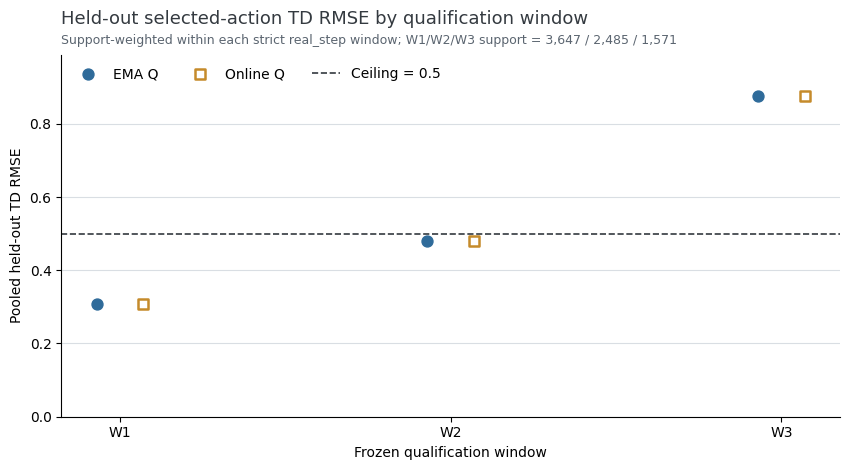

In [8]:
chart_windows = window_metrics.loc[window_metrics.window.isin(['W1', 'W2', 'W3'])].reset_index(drop=True)
x = np.arange(len(chart_windows), dtype=np.float64)
blue = '#2F6B9A'
gold = '#C58B2B'
ink = '#343A40'
grid = '#D9DEE3'

fig, ax = plt.subplots(figsize=(8.6, 4.8), facecolor='white')
ax.scatter(x - 0.07, chart_windows.ema_rmse, s=62, color=blue, marker='o', label='EMA Q', zorder=3)
ax.scatter(x + 0.07, chart_windows.online_rmse, s=62, facecolor='white', edgecolor=gold, linewidth=1.8, marker='s', label='Online Q', zorder=3)
ax.axhline(RMSE_CEILING, color=ink, linewidth=1.2, linestyle='--', label='Ceiling = 0.5', zorder=2)
ax.set_xticks(x, chart_windows.window)
ax.set_ylim(0.0, max(chart_windows[['ema_rmse', 'online_rmse']].max()) * 1.13)
ax.set_ylabel('Pooled held-out TD RMSE')
ax.set_xlabel('Frozen qualification window')
ax.set_title('Held-out selected-action TD RMSE by qualification window', loc='left', color=ink, fontsize=13, pad=22)
ax.text(0.0, 1.02, 'Support-weighted within each strict real_step window; W1/W2/W3 support = 3,647 / 2,485 / 1,571', transform=ax.transAxes, color='#5B6570', fontsize=9, va='bottom')
ax.grid(axis='y', color=grid, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=3, loc='upper left')
fig.tight_layout()
plt.show()


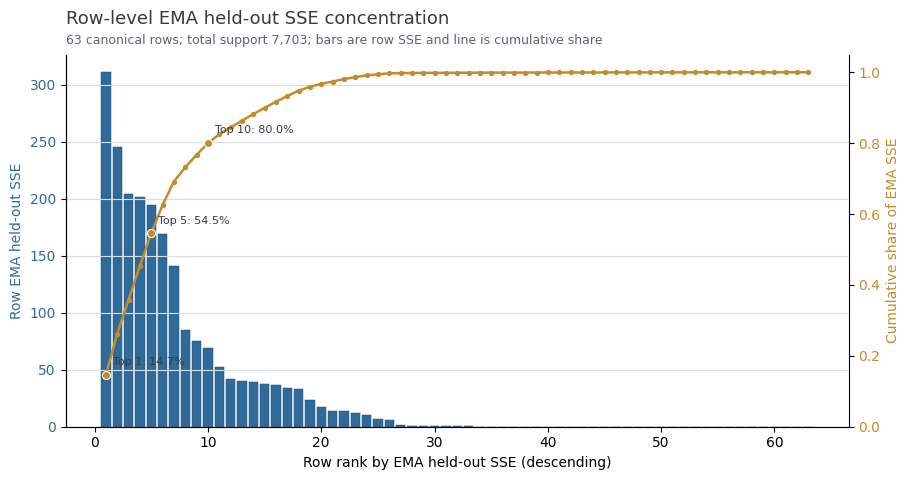

In [9]:
pareto = ranked_sse[['real_step', HOLDOUT_COUNT, 'ema_holdout_sse']].reset_index(drop=True).copy()
pareto['rank'] = np.arange(1, len(pareto) + 1)
pareto['cumulative_share'] = pareto['ema_holdout_sse'].cumsum() / pareto['ema_holdout_sse'].sum()

fig, ax = plt.subplots(figsize=(9.2, 4.9), facecolor='white')
ax.bar(pareto['rank'], pareto['ema_holdout_sse'], width=0.82, color=blue, edgecolor='#244F70', linewidth=0.35)
ax.set_xlabel('Row rank by EMA held-out SSE (descending)')
ax.set_ylabel('Row EMA held-out SSE', color=blue)
ax.tick_params(axis='y', labelcolor=blue)
ax.grid(axis='y', color=grid, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)

cumulative_ax = ax.twinx()
cumulative_ax.plot(pareto['rank'], pareto['cumulative_share'], color=gold, linewidth=1.8, marker='o', markersize=2.8)
cumulative_ax.set_ylim(0.0, 1.05)
cumulative_ax.set_ylabel('Cumulative share of EMA SSE', color=gold)
cumulative_ax.tick_params(axis='y', labelcolor=gold)
cumulative_ax.spines['top'].set_visible(False)
for top_k in (1, 5, 10):
    share = float(pareto.loc[top_k - 1, 'cumulative_share'])
    cumulative_ax.scatter([top_k], [share], s=34, color=gold, edgecolor='white', linewidth=0.8, zorder=4)
    cumulative_ax.annotate(f'Top {top_k}: {share:.1%}', (top_k, share), xytext=(5, 7), textcoords='offset points', color=ink, fontsize=8)
ax.set_title('Row-level EMA held-out SSE concentration', loc='left', color=ink, fontsize=13, pad=22)
ax.text(0.0, 1.02, '63 canonical rows; total support 7,703; bars are row SSE and line is cumulative share', transform=ax.transAxes, color='#5B6570', fontsize=9, va='bottom')
fig.tight_layout()
plt.show()


## Takeaways

1. **The qualification failure reproduces exactly.** EMA RMSE is 0.5247954789453232 on 7,703 held-out decisions, above the immutable 0.5 ceiling; online Q is marginally worse at 0.5248123566562356.
2. **The error is late-window and row concentrated.** W1 and W2 EMA RMSE are below 0.5, while W3 is 0.8753411. Ten rows contribute 79.9905% of total EMA SSE. The sign-changing window biases and small pooled bias show why a single global bias correction cannot restore the gate.
3. **EMA lag alone is not supported by this telemetry.** Online and EMA RMSE are nearly identical at full-population scale, with online slightly worse. This is descriptive evidence, not a causal ablation.
4. **Agreement metrics must not be conflated.** Online-vs-EMA delta-sign agreement is 46,420/61,714 (75.2179%), whereas EMA-Q-vs-projected-gate sign agreement is 61,715/61,715 by the separate exact-projection diagnostic.
5. **Squared-error pressure grows much faster in W3 than logged Huber.** Mean Huber to reconstructed half-MSE is W1 0.0302336→0.0320744, W2 0.0725518→0.0957708, and W3 0.4315884→0.6293499; full-window `MSE - 2*Huber` is 0.0958903061. This identifies observed tail sensitivity but does not simulate a squared-loss retrain.
6. **Historical context is non-causal.** Hash-validated v11/v12 qualification CSVs have EMA RMSE 0.2268263 and 0.1747629 under the same predicate, but their row cadence, support, execution mechanism, and training histories differ.

Overall assessment: **ready to share as descriptive sealed-run evidence**, with the explicit caveat that no counterfactual training or causal mechanism effect is identified here.
